In [1]:
import mne
from src.preprocessing.loader import load_raw, inspect_raw

print(f"MNE version: {mne.__version__}")


MNE version: 1.12.1


In [2]:
sample_path = mne.datasets.sample.data_path()
raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = load_raw(str(raw_path))

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [3]:
inspect_raw(raw)

Channels  : 376
Sampling Rate: 600.614990234375 Hz
Duration  : 277.7 seconds
Channel types: {'eeg', 'mag', 'stim', 'grad', 'eog'}


In [4]:
print("Sampling frequency :", raw.info['sfreq'])
print("Number of channels :", raw.info['nchan'])
print("Bad channels marked:", raw.info['bads'])
print("Measurement date   :", raw.info['meas_date'])
print()
print("First 10 channel names:")
print(raw.ch_names[:10])


Sampling frequency : 600.614990234375
Number of channels : 376
Bad channels marked: ['MEG 2443', 'EEG 053']
Measurement date   : 2002-12-03 19:01:10.720100+00:00

First 10 channel names:
['MEG 0113', 'MEG 0112', 'MEG 0111', 'MEG 0122', 'MEG 0123', 'MEG 0121', 'MEG 0132', 'MEG 0133', 'MEG 0131', 'MEG 0143']


In [5]:
raw_eeg = raw.copy().pick_types(eeg=True, meg=False, stim=False, eog=False)
inspect_raw(raw_eeg)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Channels  : 59
Sampling Rate: 600.614990234375 Hz
Duration  : 277.7 seconds
Channel types: {'eeg'}


In [6]:
raw_eeg.plot(duration=10, n_channels=30, title="Raw EEG - unprocessed")

Using qt as 2D backend.


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


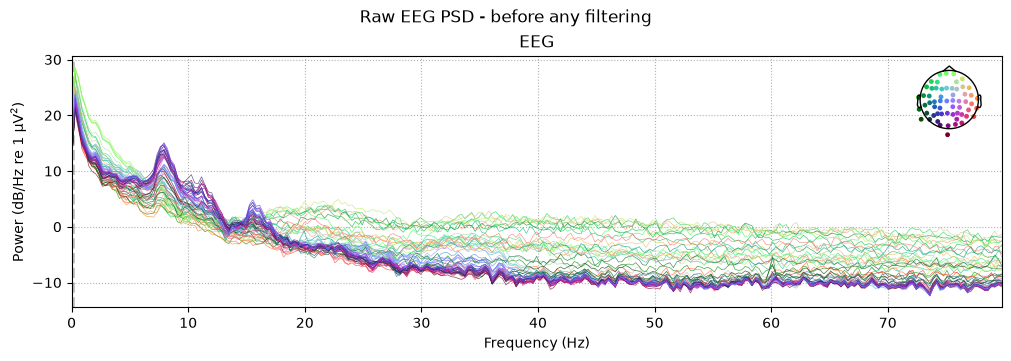

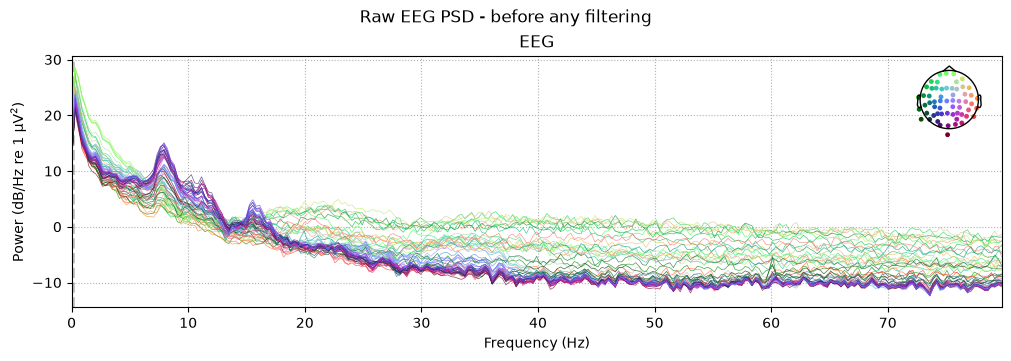

In [7]:
fig = raw_eeg.compute_psd(fmax=80).plot(picks="eeg", show=False)
fig.suptitle("Raw EEG PSD - before any filtering")
fig

In [9]:
events = mne.find_events(raw, stim_channel='STI 014')
event_id = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
    'smiley': 5,
    'buttonpress': 32,
}
print(f"Total events found: {len(events)}")
print(f"Event types: {event_id}")
print()
print("First 5 events (columns: sample_index | 0 | event_id):")
print(events[:5])
print()
print(f"Time of first event: {events[0, 0] / raw.info['sfreq']:.2f} seconds")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Total events found: 320
Event types: {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'smiley': 5, 'buttonpress': 32}

First 5 events (columns: sample_index | 0 | event_id):
[[27977     0     2]
 [28345     0     3]
 [28771     0     1]
 [29219     0     4]
 [29652     0     2]]

Time of first event: 46.58 seconds


In [10]:
import numpy as np
vals, counts = np.unique(events[:, 2], return_counts=True)
dict(zip(vals, counts))

{np.int64(1): np.int64(72),
 np.int64(2): np.int64(73),
 np.int64(3): np.int64(73),
 np.int64(4): np.int64(71),
 np.int64(5): np.int64(15),
 np.int64(32): np.int64(16)}

What I observed in M1:

Dataset: MNE auditory/visual sample - 1 subject, 277 s, 376 channels (EEG + MEG)
After picking EEG only: 59 channels at 600 Hz

Raw signal plot: 
- The signal shows a slow upward drift across the 9-second window that never completes a full cycle, meaning its frequency is below about 0.1 Hz (a full wave would take 10+ seconds). This falls in the 0-1 Hz range that M2's high-pass filter (l_freq=1.0) removes.
- No single channel looked obviously noisier than the rest at this zoom level (30 channels stacked); they were fairly uniform in amplitude and texture.
- Yes, three large sharp spikes appeared around 0.4 s, 3 s, and 4 s. They hit nearly every channel at once with the same shape, not just a few frontal ones. A real eye blink is usually strongest at the front and weaker at the back, so this pattern looks more like a shared-reference glitch or a muscle/movement artifact rather than a pure blink.

PSD:
- No clear 60 Hz spike was visible. The curves flattened into a noise floor around -10 dB by 60 Hz with no sharp peak standing out.
- A clear alpha bump was visible around 8-10 Hz, rising a few dB above the surrounding curve before dropping off again.
- Power started high (~20-25 dB) near 0 Hz, dropped steeply through the alpha bump, had a smaller secondary bump around 15-17 Hz, then flattened into a noise floor by 30-40 Hz and stayed flat out to 80 Hz.

Events:
- 320 total events found, all 6 event types present, nothing dropped.
- 145 auditory (72 left, 73 right) and 144 visual (73 left, 71 right), roughly balanced, plus 15 smiley and 16 buttonpress events.
- The first event didn't occur until 46.58 seconds in, meaning there's a ~46-second lead-in before the task actually starts.
- Excluding that lead-in, events were spaced roughly 0.6-0.75 seconds apart during the active task.

Why each upcoming module makes sense now:
- M2 filtering: I saw the slow sub-1 Hz drift and (based on the PSD) little to no clear 60 Hz spike — either way, the filter step targets both.
- M3 epoching: I found the event codes and timestamps that mark when stimuli happened — I will cut around those.
- M4 artifact rejection: the synchronized large spikes across all channels look like they need special handling — possibly not a standard blink, worth flagging for rejection or closer inspection.
- M5 ICA: if any of those spikes turn out to be eye-related after all, ICA is where they'd get isolated and removed.
- M6 ERP: after all that, averaging the auditory trials will reveal the N100 and P300.

In [11]:
meg_grad = raw.copy().pick_types(meg="grad", eeg=False)
meg_mag = raw.copy().pick_types(meg="mag", eeg=False)

print(f"Gradiometers : {len(meg_grad.ch_names)} channels")
print(f"Magnetometers: {len(meg_mag.ch_names)} channels")
print(f"EEG          : {len(raw_eeg.ch_names)} channels")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Gradiometers : 203 channels
Magnetometers: 102 channels
EEG          : 59 channels


Appendix - Why MEG channels are not processed

This dataset ships as combined EEG+MEG: 204 gradiometers, 102 magnetometers, and 60 EEG channels. This pipeline only picks EEG (`pick_types(eeg=True, meg=False)` in Cell 5) and stops there. MEG is never filtered, epoched, or analyzed anywhere in this project.

I'm not integrating MEG for a few reasons:
- MEG sensors (SQUID gradiometers and magnetometers) have different noise sources and artifact profiles than EEG. Handling them properly is its own separate project, not something you can bolt onto the EEG filter/ICA/epoch steps built in M2-M5.
- This project's goal is an EEG pipeline for BCI/neurotech applications, where EEG is the modality that actually matters here.
- MEG only shows up because this happens to be MNE's standard sample dataset, not because the project needed it.